In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from tensorflow.keras import layers, models # type: ignore
from tensorflow.keras.models import Model, load_model # type: ignore
import matplotlib.pyplot as plt
import os
import json
from PIL import Image
import shutil
from pathlib import Path

In [2]:
print("--- GPU Detection Status ---")
print(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))

--- GPU Detection Status ---
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Num GPUs Available:  1


In [3]:
source_dirs = r'C:\NEWHELPTHEGREEN\health_classifier'

In [4]:
#Step 3: Data generators with augmentations
from tensorflow.keras.preprocessing.image import ImageDataGenerator  # type: ignore

image_size = 128
batch_size = 8
train_dir = 'health_classifier/train'
val_dir = 'health_classifier/val'

# --- 1. Define Augmentation without validation_split ---
train_datagen = ImageDataGenerator(
    rescale=1./255,
    brightness_range=[0.8, 1.2],
    channel_shift_range=0.2,
    zoom_range=0.3,
    rotation_range=30,
    horizontal_flip=True,
    vertical_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    fill_mode='nearest'
)

# --- 2. Define Validation Generator (Only Rescaling) ---
val_datagen = ImageDataGenerator(rescale=1./255) 

# --- 3. Create Training Generator ---
train_gen = train_datagen.flow_from_directory(
    train_dir,
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

# --- 4. Create Validation Generator ---
val_gen = val_datagen.flow_from_directory(
    val_dir, # <-- FIX: Points to 'health_classifier/val'
    target_size=(image_size, image_size),
    batch_size=batch_size,
    class_mode='categorical',
)

num_classes = train_gen.num_classes

print(f"Number of classes detected: {num_classes}")
print(f"Classes found by generator: {train_gen.class_indices}")

Found 4944 images belonging to 2 classes.
Found 1028 images belonging to 2 classes.
Number of classes detected: 2
Classes found by generator: {'diseased': 0, 'healthy': 1}


In [5]:
import keras_tuner as kt
from tensorflow.keras.optimizers import Adam # type: ignore
from tensorflow.keras.layers import BatchNormalization # type: ignore #
from tensorflow.keras import layers, models # type: ignore
import json

# Define the model architecture for hyperparameter tuning
def build_model(hp):
    model = models.Sequential()
    
    # --- Conv Block 1 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_1_filters', 32, 128, step=32),
        kernel_size=(3, 3),
        activation='relu',
        input_shape=(image_size, image_size, 3)
    ))
    model.add(BatchNormalization()) 
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 2 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_2_filters', 64, 256, step=64),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    # --- Conv Block 3 ---
    model.add(layers.Conv2D(
        filters=hp.Int('conv_3_filters', 128, 512, step=128),
        kernel_size=(3, 3),
        activation='relu'
    ))
    model.add(BatchNormalization())
    model.add(layers.MaxPooling2D(2, 2))
    
    model.add(layers.Flatten())
    model.add(layers.Dense(
        hp.Int('dense_units', 128, 512, step=128),
        activation='relu'
    ))
    model.add(layers.Dropout(hp.Float('dropout', 0.2, 0.5, step=0.1)))
    model.add(layers.Dense(num_classes, activation='softmax'))
    
    model.compile(
        optimizer=Adam(learning_rate=hp.Float('learning_rate', 1e-5, 1e-2, sampling='log')),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the RandomSearch tuner
tuner = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=3,
    executions_per_trial=1,
    directory='keras_tuner_dir',
    project_name='HelpTheGreen'
)

print("Starting Hyperparameter Search (3 Trials x 5 Epochs each)...")
tuner.search(train_gen, epochs=5, validation_data=val_gen)
print("Hyperparameter Search Complete.")

# Get the best model and train it for 5 epochs
best_hps = tuner.get_best_hyperparameters(1)[0]
print("\nBest hyperparameters found:")
for param in best_hps.values:
    print(f"{param}: {best_hps.get(param)}")
model = tuner.hypermodel.build(best_hps)

print("\nStarting Final Model Training (5 Epochs)...")
history = model.fit(train_gen, epochs=5, validation_data=val_gen)

# Save model and class labels locally
model.save('plantvillage_tuned_model.h5')
class_labels = {v: k for k, v in train_gen.class_indices.items()}

with open('class_labels_combined.json', 'w') as f:
    json.dump(class_labels, f)

print("Final tuned model and class labels saved locally.")

Reloading Tuner from keras_tuner_dir\HelpTheGreen\tuner0.json
Starting Hyperparameter Search (3 Trials x 5 Epochs each)...
Hyperparameter Search Complete.

Best hyperparameters found:
conv_1_filters: 128
conv_2_filters: 192
conv_3_filters: 384
dense_units: 512
dropout: 0.4
learning_rate: 0.00010134724629631065

Starting Final Model Training (5 Epochs)...
Epoch 1/5
618/618 [==============================] - 299s 433ms/step - loss: 2.1691 - accuracy: 0.5983 - val_loss: 1.2582 - val_accuracy: 0.5875
Epoch 2/5
618/618 [==============================] - 113s 183ms/step - loss: 0.7929 - accuracy: 0.6252 - val_loss: 0.7061 - val_accuracy: 0.6420
Epoch 3/5
618/618 [==============================] - 107s 173ms/step - loss: 0.6707 - accuracy: 0.6483 - val_loss: 0.6924 - val_accuracy: 0.5963
Epoch 4/5
618/618 [==============================] - 93s 151ms/step - loss: 0.6241 - accuracy: 0.6604 - val_loss: 0.5679 - val_accuracy: 0.6430
Epoch 5/5
618/618 [==============================] - 102s 166ms/

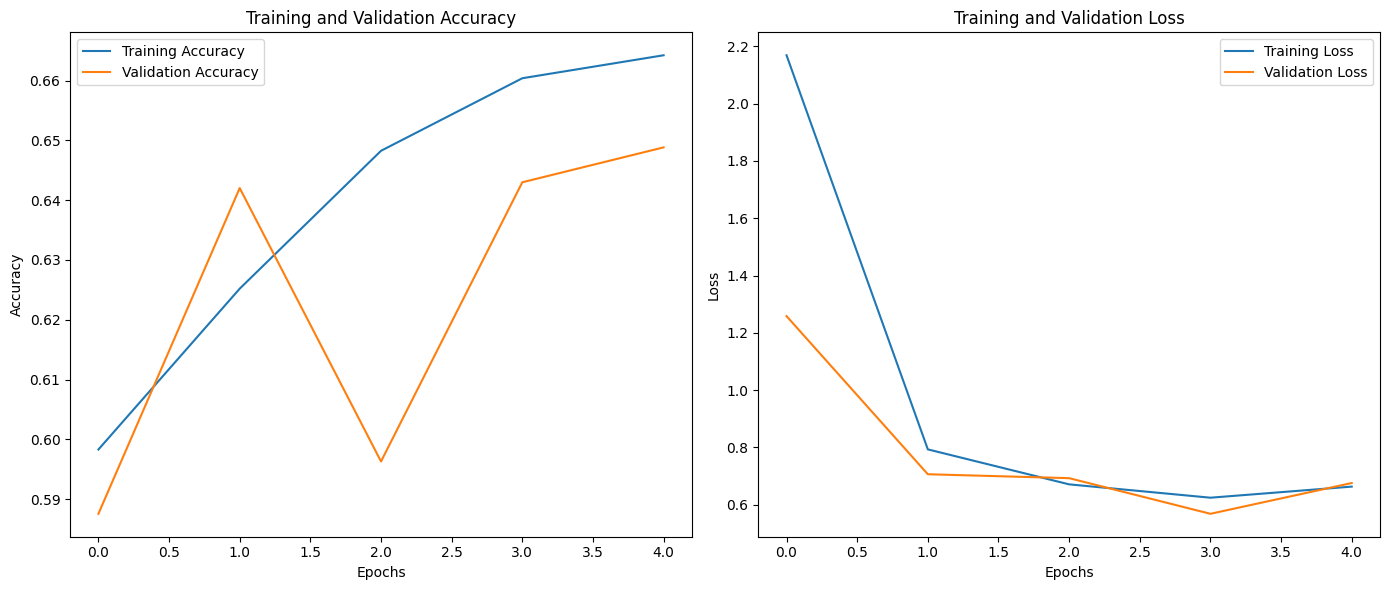

In [6]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend()
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend()
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    plt.tight_layout()
    plt.show()

plot_history(history)


In [7]:
for epoch in range(len(history.history['accuracy'])):
    print(f"Epoch {epoch+1}:")
    print(f"  Training Accuracy:  {history.history['accuracy'][epoch]:.4f}")
    print(f"  Validation Accuracy:{history.history['val_accuracy'][epoch]:.4f}")
    print(f"  Training Loss:      {history.history['loss'][epoch]:.4f}")
    print(f"  Validation Loss:    {history.history['val_loss'][epoch]:.4f}")


Epoch 1:
  Training Accuracy:  0.5983
  Validation Accuracy:0.5875
  Training Loss:      2.1691
  Validation Loss:    1.2582
Epoch 2:
  Training Accuracy:  0.6252
  Validation Accuracy:0.6420
  Training Loss:      0.7929
  Validation Loss:    0.7061
Epoch 3:
  Training Accuracy:  0.6483
  Validation Accuracy:0.5963
  Training Loss:      0.6707
  Validation Loss:    0.6924
Epoch 4:
  Training Accuracy:  0.6604
  Validation Accuracy:0.6430
  Training Loss:      0.6241
  Validation Loss:    0.5679
Epoch 5:
  Training Accuracy:  0.6642
  Validation Accuracy:0.6488
  Training Loss:      0.6629
  Validation Loss:    0.6754


Generating predictions on validation set...
129/129 [==============================] - 16s 120ms/step

--- Classification Report ---
              precision    recall  f1-score   support

    diseased       0.58      0.36      0.44       566
     healthy       0.47      0.69      0.56       462

    accuracy                           0.50      1028
   macro avg       0.52      0.52      0.50      1028
weighted avg       0.53      0.50      0.49      1028



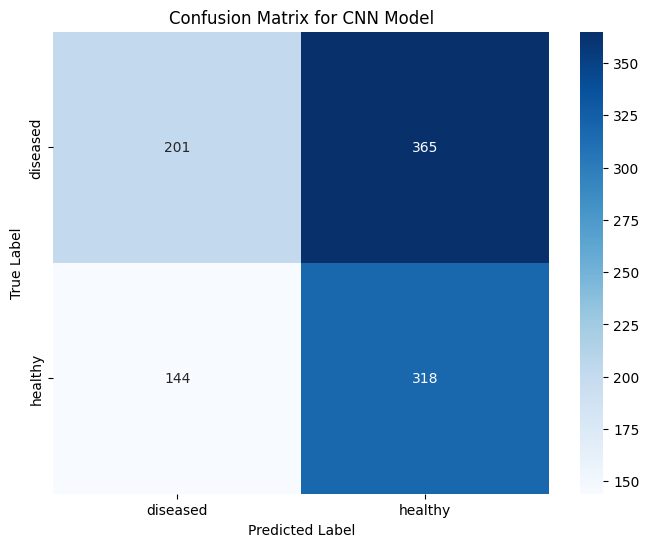

In [10]:
from sklearn.metrics import confusion_matrix, classification_report # type: ignore
import seaborn as sns # type: ignore

# 1. Get True Labels and Predictions from the Validation Set
print("Generating predictions on validation set...")

# Reset generator to ensure it starts from the beginning
val_gen.reset() 

# Predict the categories for all validation images
# steps = total number of validation samples / batch size
val_steps = val_gen.samples // val_gen.batch_size 
if val_gen.samples % val_gen.batch_size != 0:
    val_steps += 1
    
Y_pred = model.predict(val_gen, steps=val_steps)
y_pred_classes = np.argmax(Y_pred, axis=1) # Predicted classes (e.g., 0, 1)

# Get true classes (ensure generator is not shuffled)
y_true = val_gen.classes # True classes (e.g., 0, 1)

# Get class labels from the generator
class_names = list(train_gen.class_indices.keys())

# 2. Compute Confusion Matrix
conf_matrix = confusion_matrix(y_true, y_pred_classes)

# 3. Print Classification Report (Precision, Recall, F1-score)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

# 4. Plot Confusion Matrix (for report visualization)
plt.figure(figsize=(8, 6))
sns.heatmap(
    conf_matrix, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=class_names, 
    yticklabels=class_names
)
plt.title('Confusion Matrix for CNN Model')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# Prediction
import numpy as np
import json
from PIL import Image
from tensorflow.keras.models import load_model  # type: ignore
import tensorflow as tf # <-- Ensure this is imported

def load_preprocess_image(image_path, target_size=(128, 128)):
    img = Image.open(image_path).convert("RGB")
    # Resize the image
    img = img.resize(target_size)
    # Convert to NumPy array
    img_array = np.array(img)
    # Add a batch dimension (1, H, W, C)
    img_array = np.expand_dims(img_array, axis=0)
    # Normalize the pixel values to 0-1
    img_array = img_array.astype('float32') / 255
    return img_array

def predict_image(image_path):
    with tf.device('/CPU:0'):
        model = load_model(r'C:\NEWHELPTHEGREEN\plantvillage_tuned_model.h5')
    with open('class_labels_combined.json', 'r') as f:
        class_labels = json.load(f)
        class_labels = {int(k): v for k, v in class_labels.items()}
    img_array = load_preprocess_image(image_path)
    prediction = model.predict(img_array) 
    print("Top 3 Predictions:")
    top_3 = np.argsort(prediction[0])[-3:][::-1]
    for i in top_3:
        class_name = class_labels[i]
        confidence = prediction[0][i]
        print(f"{class_name}: {confidence:.2%}")

# Run the prediction using your test image
predict_image(r"C:\Users\majum\Downloads\WhatsApp Image 2025-12-14 at 03.01.00_d10c8598.jpg")

1/1 [==============================] - 1s 1s/step
Top 3 Predictions:
healthy: 93.93%
diseased: 6.07%
